In [1]:
# Imports
import pyspark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv

from pyspark.sql import SparkSession
from pyspark.sql.functions import hour, to_timestamp, unix_timestamp
import pyspark.sql.functions as F

from pyspark.ml import Pipeline
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.evaluation import RegressionEvaluator

# Start Spark
ss = SparkSession.builder.master("local").appName("accident_duration_prediction").getOrCreate()
ss.sparkContext.setLogLevel("WARN")

# Read the CSV (all columns as strings)
data = ss.read.csv("sampled_accident_data.csv", header=True, inferSchema=False)

/storage/home/jqg5993/.local/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/storage/home/jqg5993/.local/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/storage/icds/RISE/sw8/anaconda/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 15:18

In [2]:
print("Original schema:")
data.printSchema()

# Drop rows with any nulls
data = data.dropna()

print("Sample rows after dropna:")
data.show(5, truncate=False)

# Select useful columns
df = data.select(
    "ID",
    "Start_Time",
    "End_Time",
    "Severity",
    "State",
    F.col("Distance(mi)").alias("DistanceRaw")
)

Original schema:
root
 |-- ID: string (nullable = true)
 |-- Source: string (nullable = true)
 |-- Severity: string (nullable = true)
 |-- Start_Time: string (nullable = true)
 |-- End_Time: string (nullable = true)
 |-- Start_Lat: string (nullable = true)
 |-- Start_Lng: string (nullable = true)
 |-- End_Lat: string (nullable = true)
 |-- End_Lng: string (nullable = true)
 |-- Distance(mi): string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Street: string (nullable = true)
 |-- City: string (nullable = true)
 |-- County: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Zipcode: string (nullable = true)
 |-- Country: string (nullable = true)
 |-- Timezone: string (nullable = true)
 |-- Airport_Code: string (nullable = true)
 |-- Weather_Timestamp: string (nullable = true)
 |-- Temperature(F): string (nullable = true)
 |-- Wind_Chill(F): string (nullable = true)
 |-- Humidity(%): string (nullable = true)
 |-- Pressure(in): string (nullable = true)

25/12/03 15:19:00 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------+-------+--------+-------------------+-------------------+-----------------+----------+--------+------------------+------------+-------------------------------------------------------------------------+--------------------------------+--------+---------+-----+-------+-------+----------+------------+-------------------+--------------+-------------+-----------+------------+--------------+--------------+---------------+-----------------+-------------------+-------+-----+--------+--------+--------+-------+-------+----------+-------+-----+---------------+--------------+------------+--------------+--------------+-----------------+---------------------+
|ID       |Source |Severity|Start_Time         |End_Time           |Start_Lat        |Start_Lng |End_Lat |End_Lng           |Distance(mi)|Description                                                              |Street                          |City    |County   |State|Zipcode|Country|Timezone  |Airport_Code|Weather_Timestamp  |Tempe

In [3]:
# Convert times to timestamp type
df = df.withColumn("Start_ts", to_timestamp("Start_Time"))
df = df.withColumn("End_ts", to_timestamp("End_Time"))

# Compute duration in minutes
df = df.withColumn(
    "Duration_minutes",
    (unix_timestamp("End_ts") - unix_timestamp("Start_ts")) / 60.0
)

# Extract hour of day from start time
df = df.withColumn("Hour", hour("Start_ts"))

# Cast distance to numeric
df = df.withColumn("Distance", F.col("DistanceRaw").cast("double"))

# Filter out bad or extreme durations (negative or longer than 12 hours)
df = df.filter(
    (F.col("Duration_minutes") > 0) &
    (F.col("Duration_minutes") < 12 * 60)
)

# Keep only the columns we will use for modeling and drop any remaining nulls
model_df = df.select(
    "Hour",
    "Severity",
    "State",
    "Distance",
    "Duration_minutes"
).dropna()

print("Rows left for modeling:", model_df.count())
print("Schema for modeling:")
model_df.printSchema()
model_df.show(5, truncate=False)

Rows left for modeling: 34727
Schema for modeling:
root
 |-- Hour: integer (nullable = true)
 |-- Severity: string (nullable = true)
 |-- State: string (nullable = true)
 |-- Distance: double (nullable = true)
 |-- Duration_minutes: double (nullable = true)

+----+--------+-----+--------+----------------+
|Hour|Severity|State|Distance|Duration_minutes|
+----+--------+-----+--------+----------------+
|14  |2       |OH   |0.369   |360.0           |
|3   |2       |CA   |2.365   |360.0           |
|16  |3       |IL   |0.482   |360.0           |
|15  |2       |NY   |0.388   |360.0           |
|6   |2       |IL   |0.057   |360.0           |
+----+--------+-----+--------+----------------+
only showing top 5 rows


In [4]:
# Split into train and validation sets
train_df, valid_df = model_df.randomSplit([0.8, 0.2], seed=42)

# Index categorical features
severity_indexer = StringIndexer(
    inputCol="Severity",
    outputCol="Severity_idx",
    handleInvalid="keep"
)

state_indexer = StringIndexer(
    inputCol="State",
    outputCol="State_idx",
    handleInvalid="keep"
)

# Assemble features into a single vector
assembler = VectorAssembler(
    inputCols=["Hour", "Severity_idx", "State_idx", "Distance"],
    outputCol="features"
)

# Define hyperparameter grids
maxDepths = [3, 4, 5, 6]
minInstances = [2, 3]

# Evaluator for RMSE
evaluator = RegressionEvaluator(
    labelCol="Duration_minutes",
    predictionCol="prediction",
    metricName="rmse"
)

best_rmse = float("inf")
best_model = None
best_depth = None
best_minIns = None

# For recording results in a pandas table
hyperparams_eval_df = pd.DataFrame(
    columns=["maxDepth", "minInstancesPerNode", "training_rmse", "valid_rmse"]
)
index = 0

In [5]:
# Hyperparameter search
for depth in maxDepths:
    for ins in minInstances:
        print(f"\nTraining model with maxDepth={depth}, minInstancesPerNode={ins}")
        
        # IMPORTANT FIX: set maxBins high enough for State (50 categories)
        dt = DecisionTreeRegressor(
            labelCol="Duration_minutes",
            featuresCol="features",
            maxDepth=depth,
            minInstancesPerNode=ins,
            maxBins=128   # fix for "categorical feature has 50 values" error
        )
        
        pipeline = Pipeline(stages=[severity_indexer, state_indexer, assembler, dt])
        model = pipeline.fit(train_df)
        
        train_pred = model.transform(train_df)
        valid_pred = model.transform(valid_df)
        
        train_rmse = evaluator.evaluate(train_pred)
        valid_rmse = evaluator.evaluate(valid_pred)
        
        print("Training RMSE:", train_rmse)
        print("Validation RMSE:", valid_rmse)
        
        hyperparams_eval_df.loc[index] = [depth, ins, train_rmse, valid_rmse]
        index += 1
        
        if valid_rmse < best_rmse:
            best_rmse = valid_rmse
            best_model = model
            best_depth = depth
            best_minIns = ins

print("\nHyperparameter results table:")
print(hyperparams_eval_df)

print(
    "\nBest maxDepth =", best_depth,
    ", best minInstancesPerNode =", best_minIns,
    ", best validation RMSE =", best_rmse
)


Training model with maxDepth=3, minInstancesPerNode=2


Training RMSE: 96.7824450379657
Validation RMSE: 96.73912485597204

Training model with maxDepth=3, minInstancesPerNode=3


Training RMSE: 96.7824450379657
Validation RMSE: 96.73912485597204

Training model with maxDepth=4, minInstancesPerNode=2


Training RMSE: 95.97550555034702
Validation RMSE: 96.21899341542583

Training model with maxDepth=4, minInstancesPerNode=3


Training RMSE: 95.97550555034702
Validation RMSE: 96.21899341542583

Training model with maxDepth=5, minInstancesPerNode=2


Training RMSE: 95.34229150329757
Validation RMSE: 95.93140350635724

Training model with maxDepth=5, minInstancesPerNode=3


Training RMSE: 95.34229150329757
Validation RMSE: 95.93140350635724

Training model with maxDepth=6, minInstancesPerNode=2


Training RMSE: 94.59779887942099
Validation RMSE: 95.59469036501608

Training model with maxDepth=6, minInstancesPerNode=3


Training RMSE: 94.59895994010162
Validation RMSE: 95.59496711747826

Hyperparameter results table:
   maxDepth  minInstancesPerNode  training_rmse  valid_rmse
0       3.0                  2.0      96.782445   96.739125
1       3.0                  3.0      96.782445   96.739125
2       4.0                  2.0      95.975506   96.218993
3       4.0                  3.0      95.975506   96.218993
4       5.0                  2.0      95.342292   95.931404
5       5.0                  3.0      95.342292   95.931404
6       6.0                  2.0      94.597799   95.594690
7       6.0                  3.0      94.598960   95.594967

Best maxDepth = 6 , best minInstancesPerNode = 2 , best validation RMSE = 95.59469036501608



Sample predictions on validation set:


+----+--------+-----+--------+------------------+------------------+
|Hour|Severity|State|Distance|Duration_minutes  |prediction        |
+----+--------+-----+--------+------------------+------------------+
|0   |2       |AL   |0.079   |105.0             |133.03848742472547|
|0   |2       |AL   |0.464   |171.0             |133.03848742472547|
|0   |2       |AR   |0.072   |146.03333333333333|108.09715544871793|
|0   |2       |AR   |3.151   |76.33333333333333 |130.64488188976375|
|0   |2       |AZ   |0.06    |80.3              |136.508032128514  |
|0   |2       |AZ   |0.079   |77.45             |136.508032128514  |
|0   |2       |AZ   |0.464   |126.71666666666667|136.508032128514  |
|0   |2       |AZ   |3.575   |185.3             |130.64488188976375|
|0   |2       |CA   |0.0     |36.733333333333334|78.31864718614717 |
|0   |2       |CA   |0.0     |41.766666666666666|78.31864718614717 |
|0   |2       |CA   |0.0     |49.96666666666667 |78.31864718614717 |
|0   |2       |CA   |0.0     |51.7

+----+-------------------+----------------------+
|Hour|Actual_Avg_Duration|Predicted_Avg_Duration|
+----+-------------------+----------------------+
|   0| 119.05401002506267|    140.76725321816767|
|   1| 125.57119999999998|    135.60464418328394|
|   2| 137.59533333333331|     139.3398028000723|
|   3| 126.06825396825396|     141.3632268338082|
|   4|  138.0337164750958|    139.04200209122135|
|   5| 152.01154618473893|    140.32045243674054|
|   6| 148.88990442054973|     138.7711340216112|
|   7|  106.6430244941427|    116.98292330769449|
|   8| 114.70443037974677|    115.25694345214555|
|   9| 118.96955128205127|     118.9668202945298|
|  10|  129.0886617100372|     124.9569858809358|
|  11| 125.31732891832235|     120.5555257571516|
|  12| 142.63126984126987|    122.63914388812873|
|  13| 150.83135021097053|     126.6530522472932|
|  14| 129.30385620915035|    124.38945363009798|
|  15| 111.35800595238096|     113.4551575664155|
|  16| 105.90781512605038|    113.85728161953602|


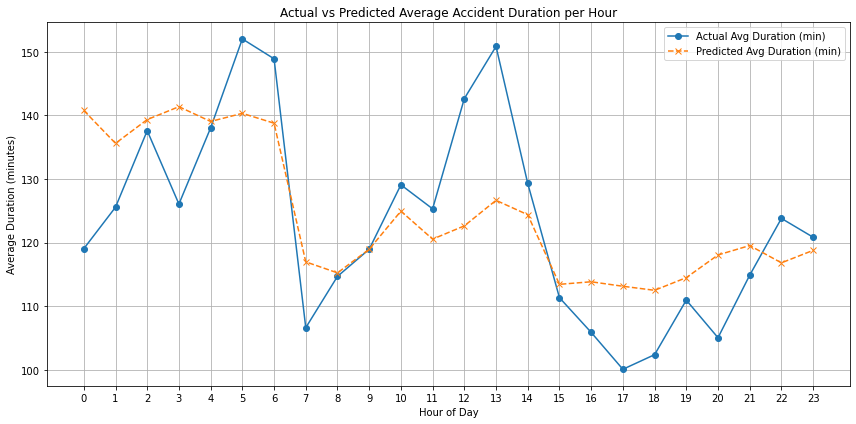

In [7]:
# Use the best model on the validation set
best_predictions = best_model.transform(valid_df)

print("\nSample predictions on validation set:")
best_predictions.select(
    "Hour",
    "Severity",
    "State",
    "Distance",
    "Duration_minutes",
    "prediction"
).show(20, truncate=False)

# Plot actual vs predicted duration for a sample of points
# Plot actual vs predicted average duration per hour (like your accident count graph)

# 1. Compute average actual and predicted duration per hour
avg_by_hour = (
    best_predictions
    .groupBy("Hour")
    .agg(
        F.avg("Duration_minutes").alias("Actual_Avg_Duration"),
        F.avg("prediction").alias("Predicted_Avg_Duration")
    )
    .orderBy("Hour")
)

avg_by_hour.show()

# 2. Convert to Pandas for plotting
avg_pd = avg_by_hour.toPandas().sort_values("Hour")

hours = avg_pd["Hour"].to_numpy()
actual_avg = avg_pd["Actual_Avg_Duration"].to_numpy()
pred_avg = avg_pd["Predicted_Avg_Duration"].to_numpy()

# 3. Line plot like your severity prediction graph
plt.figure(figsize=(12, 6))

plt.plot(hours, actual_avg, marker="o", label="Actual Avg Duration (min)")
plt.plot(hours, pred_avg, marker="x", linestyle="--", label="Predicted Avg Duration (min)")

plt.title("Actual vs Predicted Average Accident Duration per Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Duration (minutes)")
plt.xticks(hours)  # show each hour on x axis
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
ss.stop()